In [ ]:
import pandas as pd
import seaborn as sns
import ast
import numpy as np
import kagglehub

path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)
credits=pd.read_csv('/kaggle/input/the-movies-dataset/credits.csv')
keywords=pd.read_csv('/kaggle/input/the-movies-dataset/keywords.csv')
links=pd.read_csv('/kaggle/input/the-movies-dataset/links.csv')
movies=pd.read_csv('/kaggle/input/the-movies-dataset/movies_metadata.csv')
ratings=pd.read_csv('/kaggle/input/the-movies-dataset/ratings.csv')

pd.set_option('display.max_columns', None)

def parse_json_column(val):
    if isinstance(val, (list, dict)):
        return val
    if pd.isna(val) or val == '' or val == '[]' or val == '{}':
        return []

    try:
        data = ast.literal_eval(str(val))
        if isinstance(data, list):
            return [item['name'] for item in data if isinstance(item, dict) and 'name' in item]
        if isinstance(data, dict):
            return data.get('name', '')
        return []
    except (ValueError, SyntaxError):
        return []

json_cols_movies = ['genres', 'production_companies', 'production_countries', 'spoken_languages', 'belongs_to_collection']
for col in json_cols_movies:
    movies[col] = movies[col].apply(parse_json_column)

credits['cast'] = credits['cast'].apply(parse_json_column)
credits['crew'] = credits['crew'].apply(parse_json_column)

# 3. Обработка keywords
keywords['keywords'] = keywords['keywords'].apply(parse_json_column)

print("Готово!")
display(movies.head(2))
display(credits.head(2))
display(keywords.head(2))


ratings = ratings.dropna(subset=['userId', 'movieId', 'rating'])

movies['id_clean'] = pd.to_numeric(movies['id'], errors='coerce')

invalid_mask = (
    movies['id_clean'].isna() |
    movies['vote_average'].isna() |
    movies['vote_count'].isna() |
    movies.duplicated(subset=['id_clean'], keep='first')
)

movies = movies[~invalid_mask].copy()
movies['id'] = movies['id_clean'].astype(int)
movies = movies.drop(columns=['id_clean'])

print(f"Очистка завершена. Чистых строк в movies: {len(movies)}")

movies['homepage'] = movies['homepage'].notna().astype(int)

if 'poster_path' in movies.columns:
    movies = movies.drop(columns=['poster_path'])

if 'timestamp' in ratings.columns:
    ratings = ratings.drop(columns=['timestamp'])

print("Optimization complete!")
print(f"Columns in movies: {movies.columns.tolist()}")
print(f"Columns in ratings: {ratings.columns.tolist()}")
display(movies[['title', 'homepage']].head())
display(ratings.head())



valid_ids = set(movies['id'])

def clean_auxiliary_table(df, name, id_col='id'):
    print(f"--- Cleaning {name} ---")
    initial_count = len(df)

    df_clean = df.drop_duplicates(subset=[id_col], keep='first')
    duplicates_removed = initial_count - len(df_clean)

    df_clean = df_clean[df_clean[id_col].astype(float).astype(int).isin(valid_ids)]
    ids_not_in_movies = (initial_count - duplicates_removed) - len(df_clean)

    print(f"Initial rows: {initial_count}")
    print(f"Duplicates removed: {duplicates_removed}")
    print(f"Rows with IDs not in movies removed: {ids_not_in_movies}")
    print(f"Final clean rows: {len(df_clean)}")
    print("\n")
    return df_clean

credits = clean_auxiliary_table(credits, 'credits')
keywords = clean_auxiliary_table(keywords, 'keywords')

links = clean_auxiliary_table(links.dropna(subset=['tmdbId']), 'links', id_col='tmdbId')

links = links.rename(columns={'tmdbId': 'id'})
links['id'] = links['id'].astype(int)

print("Sync complete! All tables now match the movie metadata subset.")

ratings_mapped = ratings.merge(links[['movieId', 'id']], on='movieId', how='inner')


ratings_mapped = ratings_mapped.rename(columns={'id': 'tmdbId'})
ratings_mapped = ratings_mapped.drop(columns=['movieId'])

ratings = ratings_mapped[ratings_mapped['tmdbId'].isin(valid_ids)].copy()

ratings['tmdbId'] = ratings['tmdbId'].astype(int)

print(f" We now have {len(ratings):,} ratings correctly mapped to TMDB IDs.")

display(ratings.head())

Using Colab cache for faster access to the 'the-movies-dataset' dataset.
Path to dataset files: /kaggle/input/the-movies-dataset


/tmp/ipykernel_26473/2380179691.py:13: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies=pd.read_csv('/kaggle/input/the-movies-dataset/movies_metadata.csv')


Готово!


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,Toy Story Collection,30000000,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],[United States of America],1995-10-30,373554033.0,81.0,[English],Released,NaN,Toy Story,False,7.7,5415.0
1,False,[],65000000,"[Adventure, Fantasy, Family]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],1995-12-15,262797249.0,104.0,"[English, Français]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0


,cast,crew,id
0,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...","[John Lasseter, Joss Whedon, Andrew Stanton, J...",862
1,"[Robin Williams, Jonathan Hyde, Kirsten Dunst,...","[Larry J. Franco, Jonathan Hensleigh, James Ho...",8844


...

Очистка завершена. Чистых строк в movies: 45430
Optimization complete!
Columns in movies: ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']
Columns in ratings: ['userId', 'movieId', 'rating']


,title,homepage
0,Toy Story,1
1,Jumanji,0
2,Grumpier Old Men,0
3,Waiting to Exhale,0
4,Father of the Bride Part II,0


,userId,movieId,rating
0,1,110,1.0
1,1,147,4.5
2,1,858,5.0
3,1,1221,5.0
4,1,1246,5.0


--- Cleaning credits ---
Initial rows: 45476
Duplicates removed: 44
Rows with IDs not in movies removed: 3
Final clean rows: 45429


--- Cleaning keywords ---
Initial rows: 46419
Duplicates removed: 987
Rows with IDs not in movies removed: 3
Final clean rows: 45429


--- Cleaning links ---
Initial rows: 45624
Duplicates removed: 30
Rows with IDs not in movies removed: 164
Final clean rows: 45430


Sync complete! All tables now match the movie metadata subset.
 We now have 25,980,582 ratings correctly mapped to TMDB IDs.


,userId,rating,tmdbId
0,1,1.0,197
1,1,4.5,10474
2,1,5.0,238
3,1,5.0,240
4,1,5.0,207


In [ ]:
credits

,cast,crew,id
0,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...","[John Lasseter, Joss Whedon, Andrew Stanton, J...",862
1,"[Robin Williams, Jonathan Hyde, Kirsten Dunst,...","[Larry J. Franco, Jonathan Hensleigh, James Ho...",8844
2,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...","[Howard Deutch, Mark Steven Johnson, Mark Stev...",15602
3,"[Whitney Houston, Angela Bassett, Loretta Devi...","[Forest Whitaker, Ronald Bass, Ronald Bass, Ez...",31357
4,"[Steve Martin, Diane Keaton, Martin Short, Kim...","[Alan Silvestri, Elliot Davis, Nancy Meyers, N...",11862
...,...,...,...
45471,"[Leila Hatami, Kourosh Tahami, Elham Korda]","[Hamid Nematollah, Hamid Nematollah, Farshad M...",439050
45472,"[Angel Aquino, Perry Dizon, Hazel Orencio, Joe...","[Lav Diaz, Lav Diaz, Dante Perez, Lav Diaz, La...",111109
45473,"[Erika Eleniak, Adam Baldwin, Julie du Page, J...","[Mark L. Lester, C. Courtney Joyner, Jeffrey G...",67758
45474,"[Iwan Mosschuchin, Nathalie Lissenko, Pavel Pa...","[Yakov Protazanov, Joseph N. Ermolieff]",227506


In [ ]:
keywords

,id,keywords
0,862,"[jealousy, toy, boy, friendship, friends, riva..."
1,8844,"[board game, disappearance, based on children'..."
2,15602,"[fishing, best friend, duringcreditsstinger, o..."
3,31357,"[based on novel, interracial relationship, sin..."
4,11862,"[baby, midlife crisis, confidence, aging, daug..."
...,...,...
46414,439050,[tragic love]
46415,111109,"[artist, play, pinoy]"
46416,67758,[]
46417,227506,[]


In [ ]:
links

,movieId,imdbId,id
0,1,114709,862
1,2,113497,8844
2,3,113228,15602
3,4,114885,31357
4,5,113041,11862
...,...,...,...
45838,176269,6209470,439050
45839,176271,2028550,111109
45840,176273,303758,67758
45841,176275,8536,227506


In [ ]:
movies

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,Toy Story Collection,30000000,"[Animation, Comedy, Family]",1,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,[Pixar Animation Studios],[United States of America],1995-10-30,373554033.0,81.0,[English],Released,NaN,Toy Story,False,7.7,5415.0
1,False,[],65000000,"[Adventure, Fantasy, Family]",0,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],1995-12-15,262797249.0,104.0,"[English, Français]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,Grumpy Old Men Collection,0,"[Romance, Comedy]",0,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,"[Warner Bros., Lancaster Gate]",[United States of America],1995-12-22,0.0,101.0,[English],Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,[],16000000,"[Comedy, Drama, Romance]",0,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,[Twentieth Century Fox Film Corporation],[United States of America],1995-12-22,81452156.0,127.0,[English],Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,Father of the Bride Collection,0,[Comedy],0,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,"[Sandollar Productions, Touchstone Pictures]",[United States of America],1995-02-10,76578911.0,106.0,[English],Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45461,False,[],0,"[Drama, Family]",1,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,0.072051,[],[Iran],NaN,0.0,90.0,[فارسی],Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45462,False,[],0,[Drama],0,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,0.178241,[Sine Olivia],[Philippines],2011-11-17,0.0,360.0,[],Released,NaN,Century of Birthing,False,9.0,3.0
45463,False,[],0,"[Action, Drama, Thriller]",0,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",0.903007,[American World Pictures],[United States of America],2003-08-01,0.0,90.0,[English],Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45464,False,[],0,[],0,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",0.003503,[Yermoliev],[Russia],1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0


In [ ]:
ratings

,userId,rating,tmdbId
0,1,1.0,197
1,1,4.5,10474
2,1,5.0,238
3,1,5.0,240
4,1,5.0,207
...,...,...,...
25980577,270896,5.0,155
25980578,270896,5.0,10681
25980579,270896,4.5,12405
25980580,270896,4.5,4922


Количество фильмов после фильтрации (vote_count >= 5): 30879

Анализ столбца: budget
Корреляция между 'budget' и 'vote_average': 0.0636


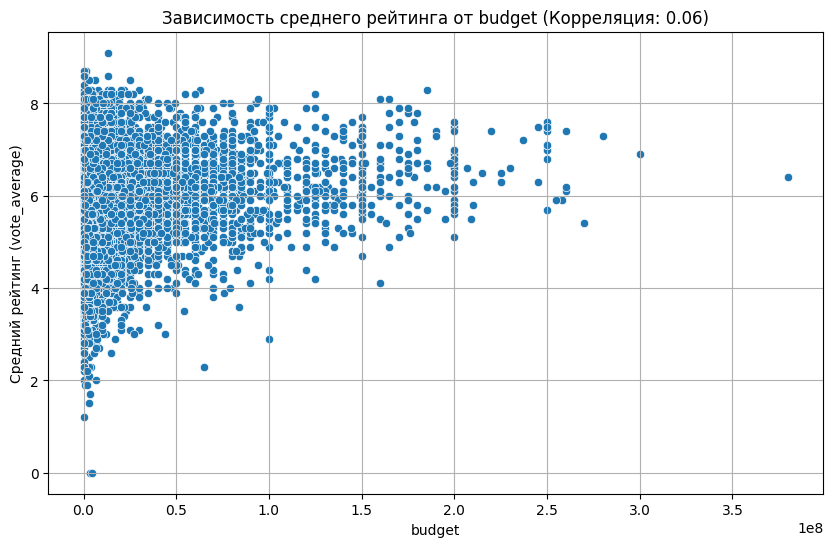


--------------------------------------------------

Анализ столбца: popularity
Корреляция между 'popularity' и 'vote_average': 0.1012


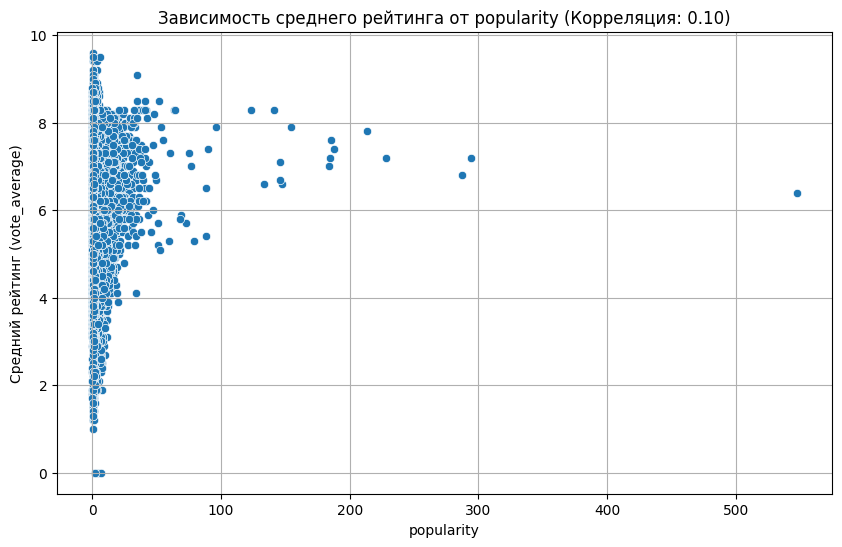


--------------------------------------------------

Анализ столбца: revenue
Корреляция между 'revenue' и 'vote_average': 0.1501


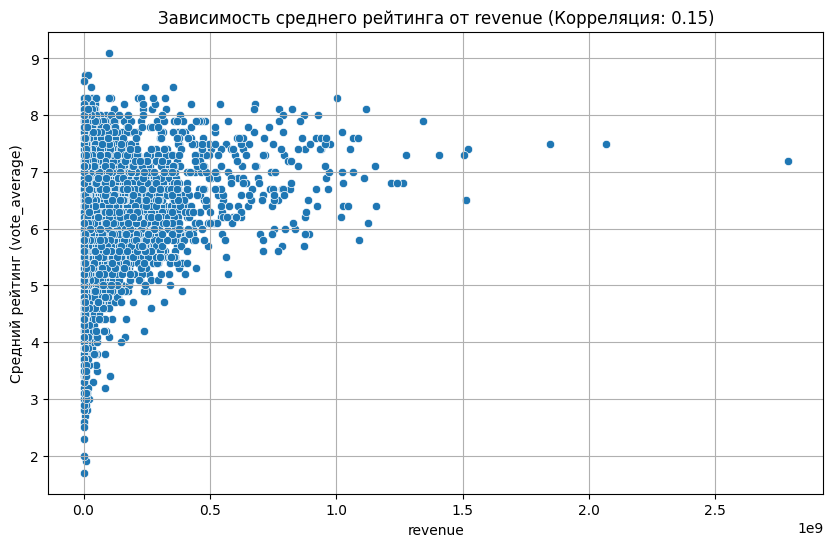


--------------------------------------------------

Анализ столбца: runtime
Корреляция между 'runtime' и 'vote_average': 0.1408


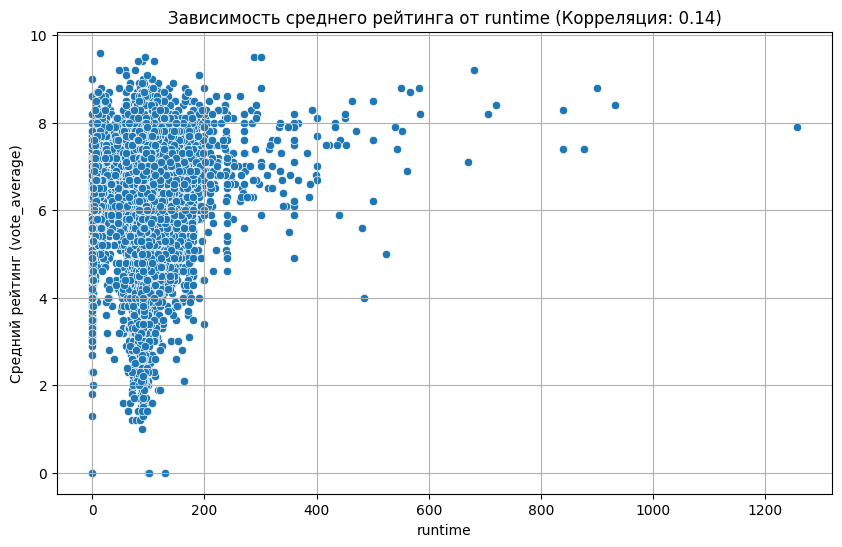


--------------------------------------------------

Анализ столбца: adult
Средние рейтинги по категориям 'adult':
adult
False    6.091280
True     4.514286
Name: vote_average, dtype: float64



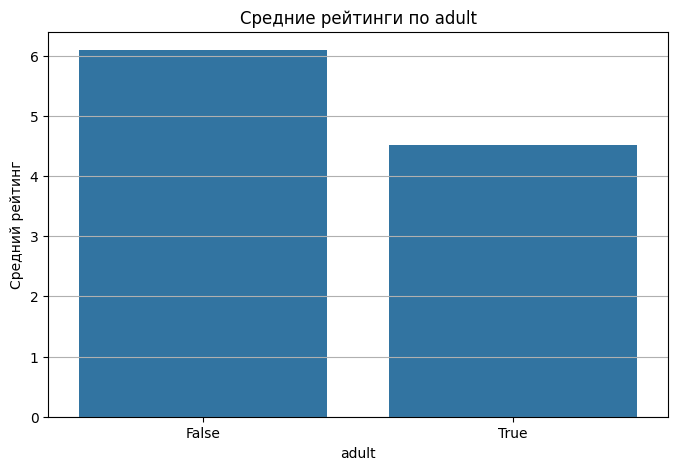


--------------------------------------------------

Анализ столбца: original_language
Топ-10 языков по среднему рейтингу (фильмов >= 5):
   original_language  average_rating  movie_count
6                 bn        7.422222           18
3                 ar        7.150000           18
9                 ca        7.142857            7
18                et        7.050000            8
11                cs        7.006024           83
20                fa        6.950909           55
66                tr        6.914851          101
67                uk        6.914286            7
65                tl        6.900000            8
29                is        6.892857           14



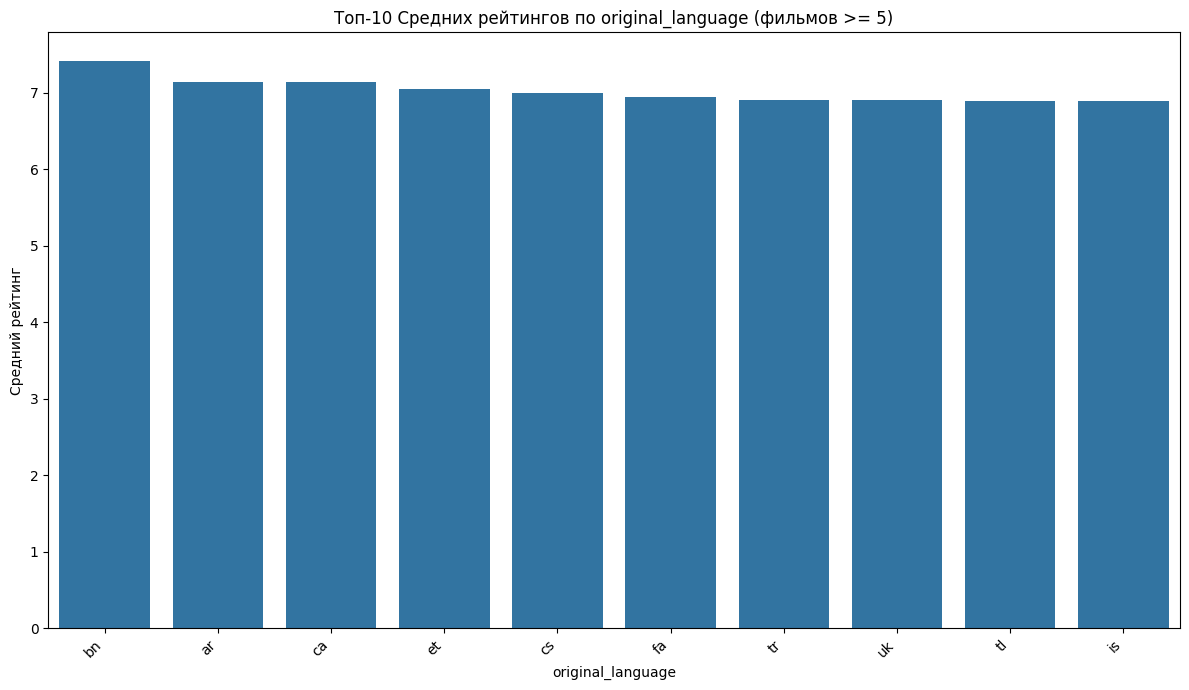


--------------------------------------------------

Анализ столбца: video
Средние рейтинги по категориям 'video':
video
True     7.119355
False    6.089889
Name: vote_average, dtype: float64



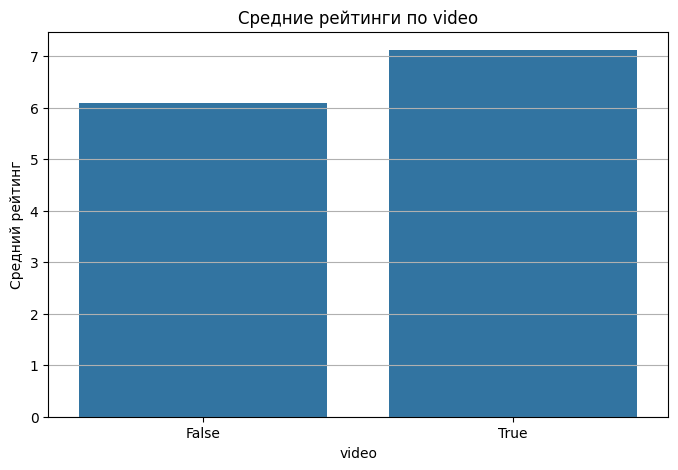


--------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter movies with at least 5 votes for more reliable average ratings
movies_filtered = movies[movies['vote_count'] >= 5].copy()

# Convert 'budget' and 'revenue' to numeric types upfront
# This ensures that comparisons like `> 0` work correctly and prevents TypeError
movies_filtered['budget'] = pd.to_numeric(movies_filtered['budget'], errors='coerce')
movies_filtered['revenue'] = pd.to_numeric(movies_filtered['revenue'], errors='coerce')

print(f"Количество фильмов после фильтрации (vote_count >= 5): {len(movies_filtered)}\n")

# --- Анализ числовых столбцов (корреляция и scatter plot) ---

numerical_cols = ['budget', 'popularity', 'revenue', 'runtime']

for col in numerical_cols:
    if col not in movies_filtered.columns:
        print(f"Столбец '{col}' не найден в датафрейме 'movies'. Пропускаем.\n")
        continue

    print(f"Анализ столбца: {col}")

    # Применяем дополнительные фильтры для budget и revenue
    if col in ['budget', 'revenue']:
        # Ensure filtering is done on numeric values, NaN will be excluded by `> 0`
        df_for_analysis = movies_filtered[movies_filtered[col] > 0].copy()
        if df_for_analysis.empty:
            print(f"После фильтрации '{col} > 0' и 'vote_count >= 5' не осталось данных для анализа. Пропускаем.\n")
            continue
    else:
        df_for_analysis = movies_filtered.copy()

    # Убедимся, что столбец имеет числовой тип (redundant for budget/revenue now, but good practice for others)
    df_for_analysis[col] = pd.to_numeric(df_for_analysis[col], errors='coerce')
    df_for_analysis = df_for_analysis.dropna(subset=[col, 'vote_average'])

    if not df_for_analysis.empty:
        correlation = df_for_analysis[col].corr(df_for_analysis['vote_average'])
        print(f"Корреляция между '{col}' и 'vote_average': {correlation:.4f}")

        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=col, y='vote_average', data=df_for_analysis)
        plt.title(f'Зависимость среднего рейтинга от {col} (Корреляция: {correlation:.2f})')
        plt.xlabel(col)
        plt.ylabel('Средний рейтинг (vote_average)')
        plt.grid(True)
        plt.show()
    else:
        print(f"Недостаточно данных для анализа {col} после очистки.\n")
    print("\n" + "-"*50 + "\n")

# --- Анализ категориальных столбцов (средний рейтинг по категориям) ---

categorical_cols = ['adult', 'original_language', 'video']

for col in categorical_cols:
    if col not in movies_filtered.columns:
        print(f"Столбец '{col}' не найден в датафрейме 'movies'. Пропускаем.\n")
        continue

    print(f"Анализ столбца: {col}")

    # Проверяем на наличие пустых значений и обрабатываем их
    df_for_analysis = movies_filtered.dropna(subset=[col, 'vote_average']).copy()

    if not df_for_analysis.empty:
        # Для 'original_language' может быть много уникальных значений, отобразим топ-10
        if col == 'original_language':
            # Calculate mean rating and count for each language
            language_stats = df_for_analysis.groupby(col).agg(
                average_rating=('vote_average', 'mean'),
                movie_count=('vote_average', 'count')
            ).reset_index()

            # Filter languages with at least 5 movies
            language_stats_filtered = language_stats[language_stats['movie_count'] >= 5]

            # Sort by average rating and take top 10
            avg_ratings = language_stats_filtered.sort_values(by='average_rating', ascending=False).head(10)

            print(f"Топ-10 языков по среднему рейтингу (фильмов >= 5):\n{avg_ratings[['original_language', 'average_rating', 'movie_count']]}\n")
            plt.figure(figsize=(12, 7))
            sns.barplot(x='original_language', y='average_rating', data=avg_ratings)
            plt.title(f'Топ-10 Средних рейтингов по {col} (фильмов >= 5)')
            plt.xlabel(col)
            plt.ylabel('Средний рейтинг')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        else:
            avg_ratings = df_for_analysis.groupby(col)['vote_average'].mean().sort_values(ascending=False)
            print(f"Средние рейтинги по категориям '{col}':\n{avg_ratings}\n")
            plt.figure(figsize=(8, 5))
            sns.barplot(x=avg_ratings.index, y=avg_ratings.values)
            plt.title(f'Средние рейтинги по {col}')
            plt.xlabel(col)
            plt.ylabel('Средний рейтинг')
            plt.grid(axis='y')
            plt.show()
    else:
        print(f"Недостаточно данных для анализа {col} после очистки.\n")
    print("\n" + "-"*50 + "\n")


### Анализ средних оценок по жанрам

Проанализируем средние оценки фильмов по жанрам, учитывая только те жанры, в которых представлено не менее 10 фильмов для обеспечения статистической значимости.

Анализ столбца: 'genres'

Жанры со средним рейтингом (фильмов >= 10):
         genres  average_rating  movie_count
    Documentary        6.867709         1855
        History        6.580266         1054
      Animation        6.531712         1583
          Music        6.457936         1027
            War        6.442797          951
          Drama        6.309800        14541
          Crime        6.215941         3375
        Romance        6.152787         4933
        Foreign        6.146462          975
        Mystery        6.089903         1951
         Comedy        6.034061         9806
         Family        6.002686         2234
        Fantasy        5.996050         1924
      Adventure        5.972038         2861
        Western        5.903008          665
         Action        5.829247         5375
       Thriller        5.812760         6301
       TV Movie        5.755186          511
Science Fiction        5.552556         2563
         Horror        5.37067

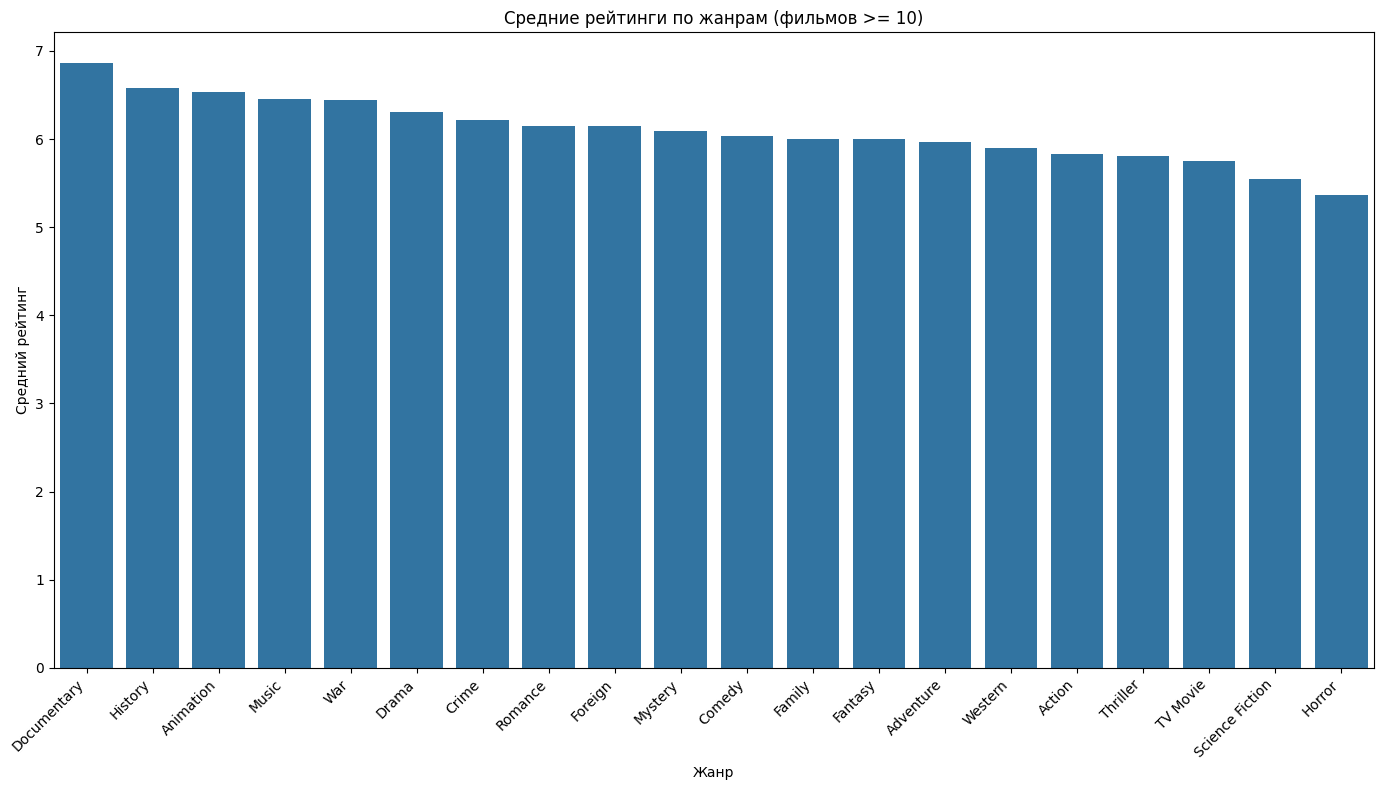


--------------------------------------------------



In [ ]:
# Анализ жанров
print(f"Анализ столбца: 'genres'\n")

# Разворачиваем столбец 'genres', так как у фильма может быть несколько жанров
df_genres = movies_filtered.explode('genres')

# Удаляем пустые значения или пустые списки, если они остались после explode
df_genres = df_genres[df_genres['genres'].astype(bool)]

if not df_genres.empty:
    genre_stats = df_genres.groupby('genres').agg(
        average_rating=('vote_average', 'mean'),
        movie_count=('genres', 'count')
    ).reset_index()

    # Фильтруем жанры, у которых хотя бы 10 фильмов
    genre_stats_filtered = genre_stats[genre_stats['movie_count'] >= 10]

    # Сортируем по среднему рейтингу в порядке убывания
    avg_ratings_genres = genre_stats_filtered.sort_values(by='average_rating', ascending=False)

    print(f"Жанры со средним рейтингом (фильмов >= 10):\n{avg_ratings_genres.to_string(index=False)}\n")

    plt.figure(figsize=(14, 8))
    sns.barplot(x='genres', y='average_rating', data=avg_ratings_genres.head(20)) # Отображаем топ-20 жанров
    plt.title(f'Средние рейтинги по жанрам (фильмов >= 10)')
    plt.xlabel('Жанр')
    plt.ylabel('Средний рейтинг')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"Недостаточно данных для анализа жанров после очистки.\n")
print("\n" + "-"*50 + "\n")

### Анализ пользовательских оценок (DataFrame `ratings`)

Теперь перейдем к анализу данных о пользовательских оценках, хранящихся в DataFrame `ratings`. Сначала посмотрим на общее распределение типов оценок, а затем на количество оценок для каждого фильма.

#### 1. Распределение типов оценок

Посмотрим, как распределяются оценки (1.0, 1.5, ..., 5.0) по всему набору данных.

Распределение оценок:

rating
0.5     403716
1.0     842074
1.5     403011
2.0    1760410
2.5    1253462
3.0    5251286
3.5    3110810
4.0    6987729
4.5    2164937
5.0    3803147
Name: count, dtype: int64


/tmp/ipykernel_15291/3368942242.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_distribution.index, y=rating_distribution.values, palette='viridis')


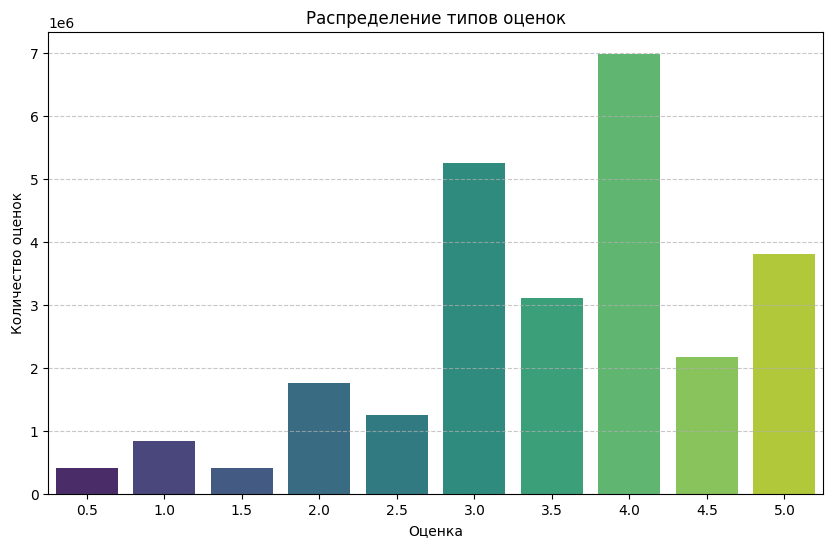

In [ ]:
# Распределение типов оценок
rating_distribution = ratings['rating'].value_counts().sort_index()

print("Распределение оценок:\n")
print(rating_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_distribution.index, y=rating_distribution.values, palette='viridis')
plt.title('Распределение типов оценок')
plt.xlabel('Оценка')
plt.ylabel('Количество оценок')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 2. Распределение количества оценок для фильмов

Изучим, сколько оценок получает каждый фильм, чтобы понять, насколько активно пользователи оценивают разные фильмы.

Описательная статистика по количеству оценок на фильм:

count    44708.000000
mean       581.117071
std       3050.263586
min          1.000000
25%          2.000000
50%          8.000000
75%         69.250000
max      91921.000000
Name: rating_count, dtype: float64


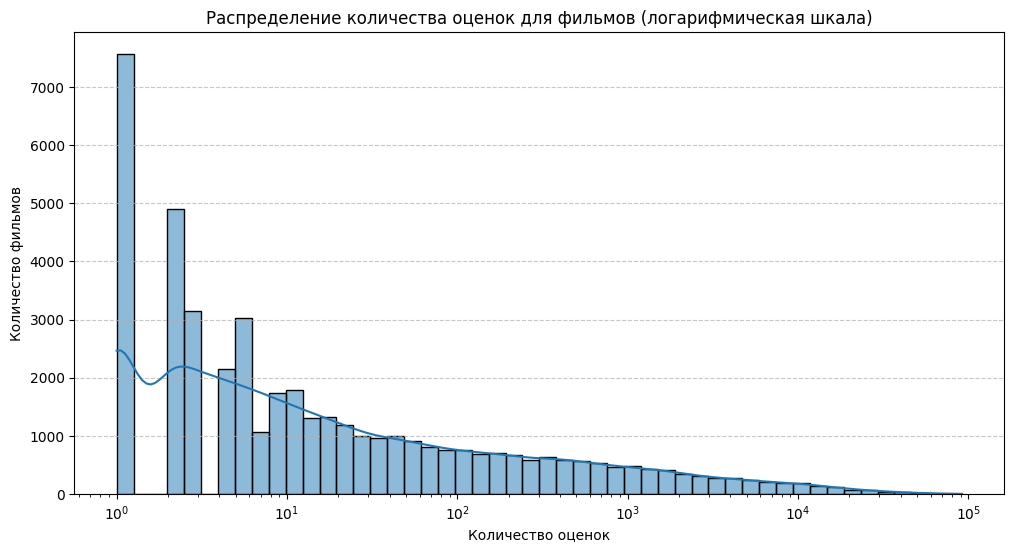

,title,vote_average,vote_count
0,Toy Story,7.7,5415.0
108,Braveheart,7.7,3404.0
256,Star Wars,8.1,6778.0
292,Pulp Fiction,8.3,8670.0
314,The Shawshank Redemption,8.5,8358.0
351,Forrest Gump,8.2,8147.0
475,Jurassic Park,7.6,4956.0
522,Schindler's List,8.3,4436.0
586,The Silence of the Lambs,8.1,4549.0
2458,The Matrix,7.9,9079.0


In [ ]:
# Количество оценок для каждого фильма
ratings_per_movie = ratings.groupby('tmdbId').size().reset_index(name='rating_count')

print("Описательная статистика по количеству оценок на фильм:\n")
print(ratings_per_movie['rating_count'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(ratings_per_movie['rating_count'], bins=50, log_scale=True, kde=True)
plt.title('Распределение количества оценок для фильмов (логарифмическая шкала)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Также посмотрим на топ-10 самых оцениваемых фильмов
top_rated_movies_ids = ratings_per_movie.sort_values(by='rating_count', ascending=False).head(10)['tmdbId']
top_rated_movies_info = movies[movies['id'].isin(top_rated_movies_ids)][['title', 'vote_average', 'vote_count']]
display(top_rated_movies_info)

In [ ]:
# Получаем топ-10 фильмов по rating_count из ratings_per_movie
top_10_rated_movies = ratings_per_movie.sort_values(by='rating_count', ascending=True).head(10)

# Объединяем с DataFrame movies, чтобы получить названия фильмов
top_10_rated_movies_with_titles = pd.merge(
    top_10_rated_movies,
    movies[['id', 'title']],
    left_on='tmdbId',
    right_on='id',
    how='left'
)

# Выводим результат
display(top_10_rated_movies_with_titles[['title', 'rating_count']])


,title,rating_count
0,Preston Sturges: The Rise and Fall of an Ameri...,1
1,Nice Places to Die,1
2,Ivanka Trump- America's Real First Lady?,1
3,Thick Lashes of Lauri Mäntyvaara,1
4,The Sex and Violence Family Hour,1
5,Traitors,1
6,Welcome to 18,1
7,Start Liquidation,1
8,Tercera Llamada,1
9,Badges of Fury,1


#### 3. Анализ процентного распределения фильмов по количеству оценок (1-10)

Процент фильмов по количеству оценок (от 1 до 10):
rating_count
1     16.918672
2     10.975664
3      7.025588
4      4.826877
5      3.717455
6      3.050908
7      2.370940
8      2.073454
9      1.805046
10     1.485193


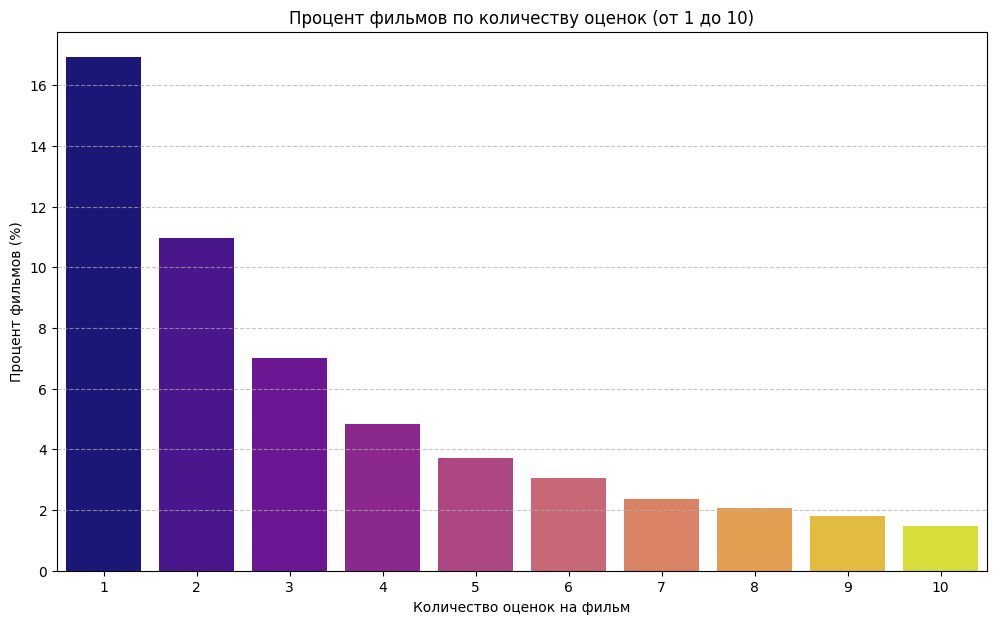

In [ ]:
# Рассчитываем количество фильмов для каждого числа оценок (от 1 до 10)
rating_counts_distribution = ratings_per_movie['rating_count'].value_counts().sort_index()

# Фильтруем только до 10 оценок, как запрашивал пользователь
rating_counts_distribution_filtered = rating_counts_distribution[rating_counts_distribution.index <= 10]

# Рассчитываем общий процент от всех фильмов
total_movies = len(ratings_per_movie)
percentage_distribution = (rating_counts_distribution_filtered / total_movies) * 100

print("Процент фильмов по количеству оценок (от 1 до 10):")
print(percentage_distribution.to_string())

plt.figure(figsize=(12, 7))
sns.barplot(x=percentage_distribution.index, y=percentage_distribution.values, hue=percentage_distribution.index, palette='plasma', legend=False)
plt.title('Процент фильмов по количеству оценок (от 1 до 10)')
plt.xlabel('Количество оценок на фильм')
plt.ylabel('Процент фильмов (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Количество уникальных пользователей: 270,883

Описательная статистика по количеству оценок на пользователя:

count    270883.000000
mean         95.910714
std         205.281852
min           1.000000
25%          15.000000
50%          30.000000
75%          93.000000
max       18216.000000
Name: rating_count, dtype: float64


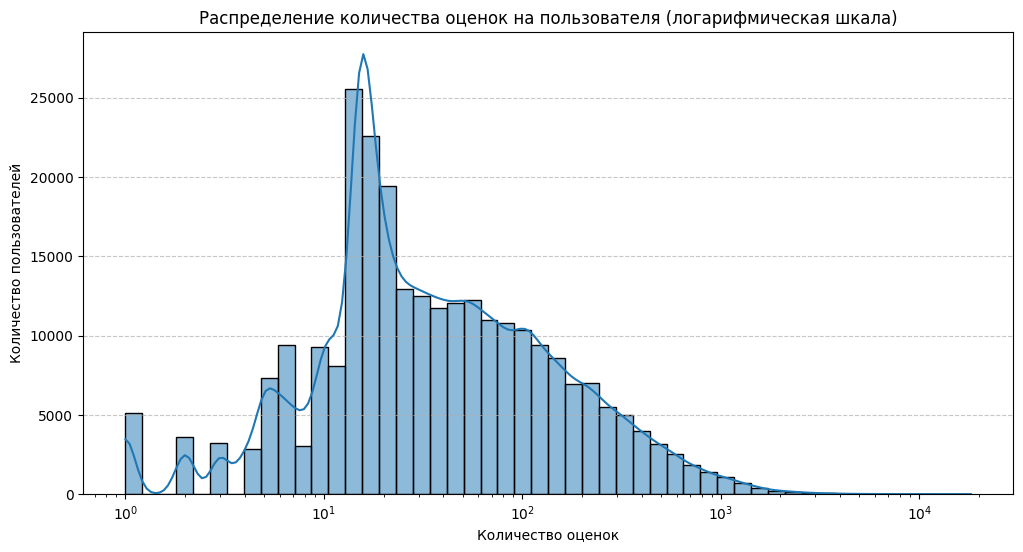


Процент пользователей по количеству оценок (от 1 до 10):
rating_count
1    1.881624
2    1.333048
3    1.199411
4    1.061344
5    2.698582


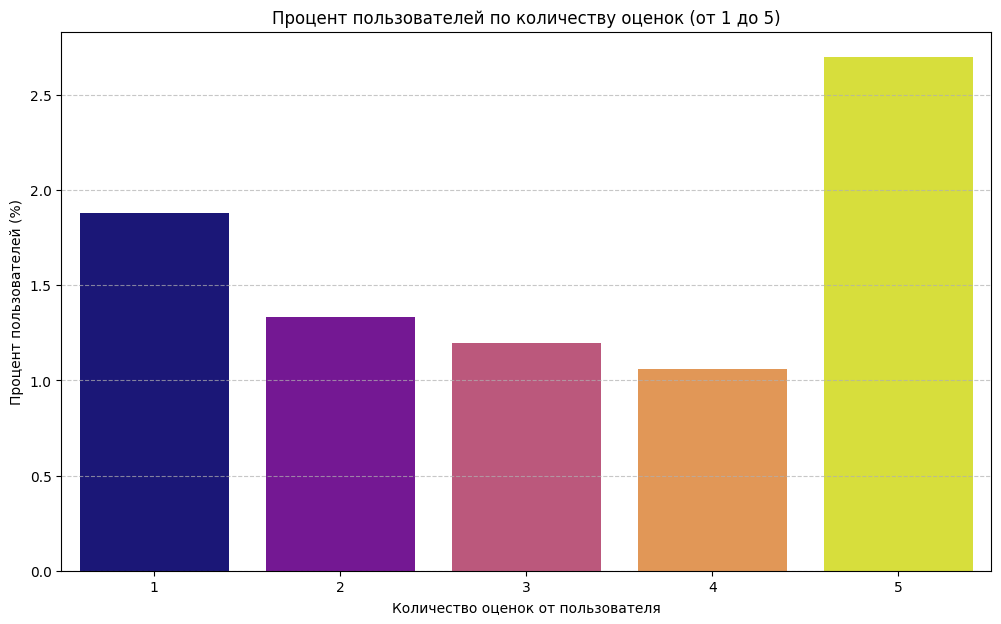

In [ ]:
print(f"Количество уникальных пользователей: {ratings['userId'].nunique():,}")

# Группировка по userId и подсчет количества оценок на пользователя
ratings_per_user = ratings.groupby('userId').size().reset_index(name='rating_count')

print("\nОписательная статистика по количеству оценок на пользователя:\n")
print(ratings_per_user['rating_count'].describe())

# Гистограмма распределения количества оценок на пользователя
plt.figure(figsize=(12, 6))
sns.histplot(ratings_per_user['rating_count'], bins=50, log_scale=True, kde=True)
plt.title('Распределение количества оценок на пользователя (логарифмическая шкала)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Рассчитываем количество пользователей для каждого числа оценок (от 1 до 10)
user_rating_counts_distribution = ratings_per_user['rating_count'].value_counts().sort_index()

# Фильтруем только до 10 оценок
user_rating_counts_distribution_filtered = user_rating_counts_distribution[user_rating_counts_distribution.index <= 5]

# Рассчитываем общий процент от всех пользователей
total_users = len(ratings_per_user)
percentage_distribution_users = (user_rating_counts_distribution_filtered / total_users) * 100

print("\nПроцент пользователей по количеству оценок (от 1 до 10):")
print(percentage_distribution_users.to_string())

plt.figure(figsize=(12, 7))
sns.barplot(x=percentage_distribution_users.index, y=percentage_distribution_users.values, hue=percentage_distribution_users.index, palette='plasma', legend=False)
plt.title('Процент пользователей по количеству оценок (от 1 до 5)')
plt.xlabel('Количество оценок от пользователя')
plt.ylabel('Процент пользователей (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Анализ среднего рейтинга для пользователей с разным количеством оценок

Теперь давайте посмотрим, как средний рейтинг, который ставит пользователь, зависит от общего количества оценок, которые он сделал.

Средний рейтинг пользователей в зависимости от количества оценок (для пользователей с >= 5 оценок):


,rating_count,rating
0,5,3.606088
1,6,3.608264
2,7,3.630246
3,8,3.635027
4,9,3.616726
5,10,3.587103
6,11,3.642869
7,12,3.683848
8,13,3.679336
9,14,3.617612


,rating_count,rating
2058,5686,3.748065
2059,5805,2.436951
2060,6006,3.498418
2061,6076,2.804477
2062,6287,1.568793
2063,7383,3.219897
2064,7501,3.208306
2065,7621,2.597231
2066,9242,3.277916
2067,18216,3.197958


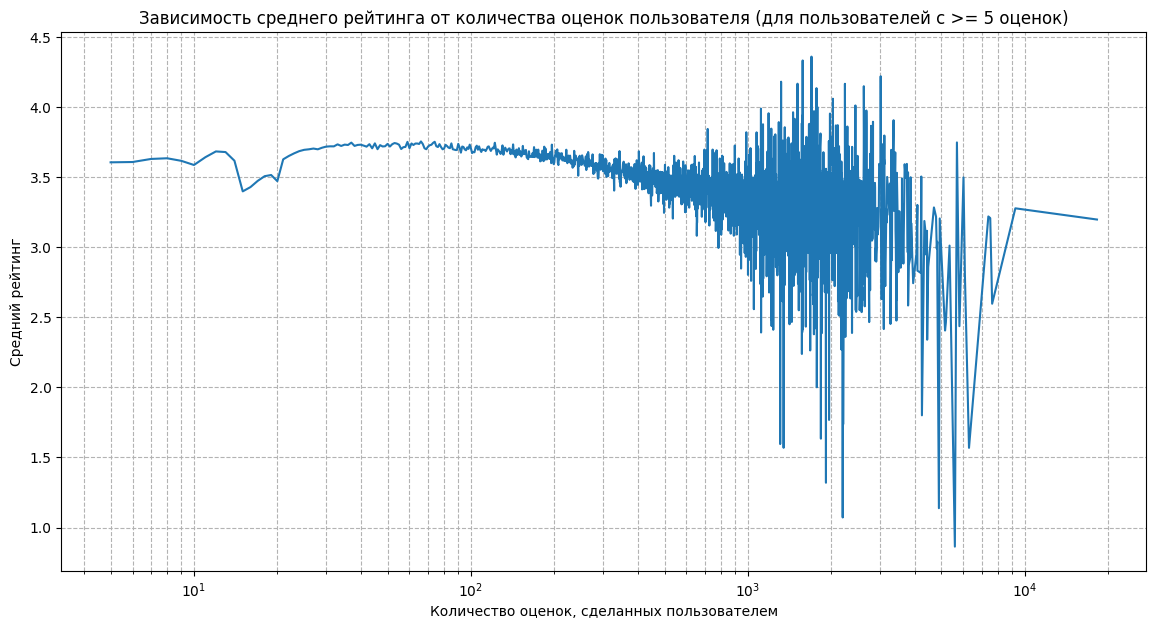

In [ ]:
# Объединяем информацию о количестве оценок на пользователя с таблицей всех оценок
# Это позволит нам сопоставить каждую оценку с количеством оценок, сделанных данным пользователем
ratings_with_user_activity = pd.merge(
    ratings,
    ratings_per_user[['userId', 'rating_count']],
    on='userId',
    how='left'
)

# Рассчитываем средний рейтинг для каждой группы пользователей с одинаковым количеством оценок
# Фильтруем, чтобы рассматривать только пользователей, сделавших не менее 5 оценок, для большей статистической значимости
min_ratings_for_avg = 5
avg_rating_by_user_activity = ratings_with_user_activity[
    ratings_with_user_activity['rating_count'] >= min_ratings_for_avg
].groupby('rating_count')['rating'].mean().reset_index()

# Отсортируем по убыванию количества оценок, чтобы увидеть тенденцию
avg_rating_by_user_activity_sorted = avg_rating_by_user_activity.sort_values(by='rating_count', ascending=True)

print(f"Средний рейтинг пользователей в зависимости от количества оценок (для пользователей с >= {min_ratings_for_avg} оценок):")
# Для краткости выведем первые 10 и последние 10, так как данных может быть много
display(avg_rating_by_user_activity_sorted.head(10))
display(avg_rating_by_user_activity_sorted.tail(10))

plt.figure(figsize=(14, 7))
sns.lineplot(x='rating_count', y='rating', data=avg_rating_by_user_activity_sorted)
plt.title('Зависимость среднего рейтинга от количества оценок пользователя (для пользователей с >= 5 оценок)')
plt.xlabel('Количество оценок, сделанных пользователем')
plt.ylabel('Средний рейтинг')
plt.xscale('log') # Используем логарифмическую шкалу для 'rating_count', так как диапазон очень большой
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

### Группировка пользователей по средней оценке

Теперь, когда мы знаем, что есть пользователи с различной средней оценкой, давайте разделим их на 5 групп (квантилей) на основе их среднего рейтинга. Это позволит нам лучше понять распределение пользователей по "строгости" их оценок, учитывая только тех, кто оставил достаточно оценок (более 4), чтобы среднее значение было статистически значимым.

Распределение пользователей по группам средней оценки (0 - низкая, 4 - высокая):
rating_group
0    51230
1    51324
2    51078
3    51221
4    51198
Name: count, dtype: int64


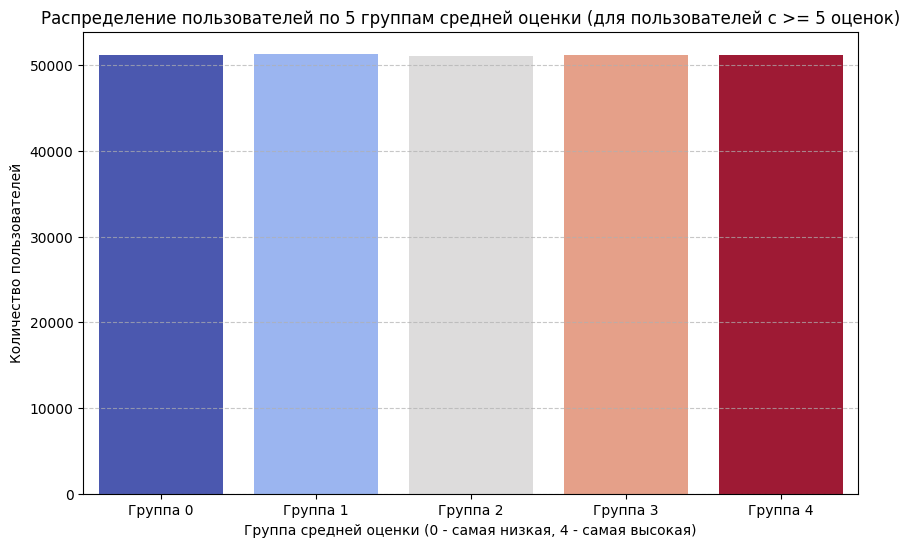


Примеры пользователей из каждой группы (первые 5):

Группа 0 (средняя оценка: 0.50-3.23):


,userId,average_rating,rating_group
2,3,3.100000,0
6,8,2.991150,0
9,11,3.214602,0
11,13,2.818182,0
17,19,2.266667,0



Группа 1 (средняя оценка: 3.23-3.53):


,userId,average_rating,rating_group
1,2,3.318182,1
3,4,3.500000,1
5,7,3.367925,1
12,14,3.400000,1
22,24,3.474763,1



Группа 2 (средняя оценка: 3.53-3.77):


,userId,average_rating,rating_group
13,15,3.736726,2
15,17,3.583333,2
24,26,3.600000,2
25,27,3.643750,2
26,28,3.642857,2



Группа 3 (средняя оценка: 3.77-4.04):


,userId,average_rating,rating_group
7,9,3.851190,3
10,12,3.854839,3
18,20,3.845725,3
21,23,3.833333,3
28,30,3.950000,3



Группа 4 (средняя оценка: 4.04-5.00):


,userId,average_rating,rating_group
0,1,4.277778,4
4,5,4.269231,4
8,10,4.230769,4
14,16,4.417582,4
16,18,4.166667,4


In [ ]:
# 1. Вычисляем средний рейтинг для каждого пользователя, который сделал >= 5 оценок
# Мы уже имеем ratings_with_user_activity и min_ratings_for_avg = 5 из предыдущей ячейки
users_avg_rating = ratings_with_user_activity[ratings_with_user_activity['rating_count'] >= min_ratings_for_avg]
users_avg_rating = users_avg_rating.groupby('userId')['rating'].mean().reset_index()
users_avg_rating.rename(columns={'rating': 'average_rating'}, inplace=True)

# 2. Создаем 5 групп на основе средней оценки (по квантилям)
# 'labels=False' для получения числовых меток (0 до 4) или можно использовать свои метки
users_avg_rating['rating_group'] = pd.qcut(users_avg_rating['average_rating'], q=5, labels=False, precision=1)

# 3. Подсчитываем количество пользователей в каждой группе
user_group_distribution = users_avg_rating['rating_group'].value_counts().sort_index()

print("Распределение пользователей по группам средней оценки (0 - низкая, 4 - высокая):")
print(user_group_distribution)

# 4. Визуализация распределения
plt.figure(figsize=(10, 6))
sns.barplot(x=user_group_distribution.index, y=user_group_distribution.values, hue=user_group_distribution.index, palette='coolwarm', legend=False)
plt.title(f'Распределение пользователей по 5 группам средней оценки (для пользователей с >= {min_ratings_for_avg} оценок)')
plt.xlabel('Группа средней оценки (0 - самая низкая, 4 - самая высокая)')
plt.ylabel('Количество пользователей')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Группа 0', 'Группа 1', 'Группа 2', 'Группа 3', 'Группа 4'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nПримеры пользователей из каждой группы (первые 5):")
for i in range(5):
    print(f"\nГруппа {i} (средняя оценка: {users_avg_rating[users_avg_rating['rating_group'] == i]['average_rating'].min():.2f}-{users_avg_rating[users_avg_rating['rating_group'] == i]['average_rating'].max():.2f}):")
    display(users_avg_rating[users_avg_rating['rating_group'] == i].head())

### Распределение пользователей по средней оценке

Прежде чем делить пользователей на новые группы, давайте сначала визуализируем общее распределение средней оценки пользователей (с не менее чем 5 оценками). Это поможет нам понять, где можно установить естественные границы для более выраженных групп.

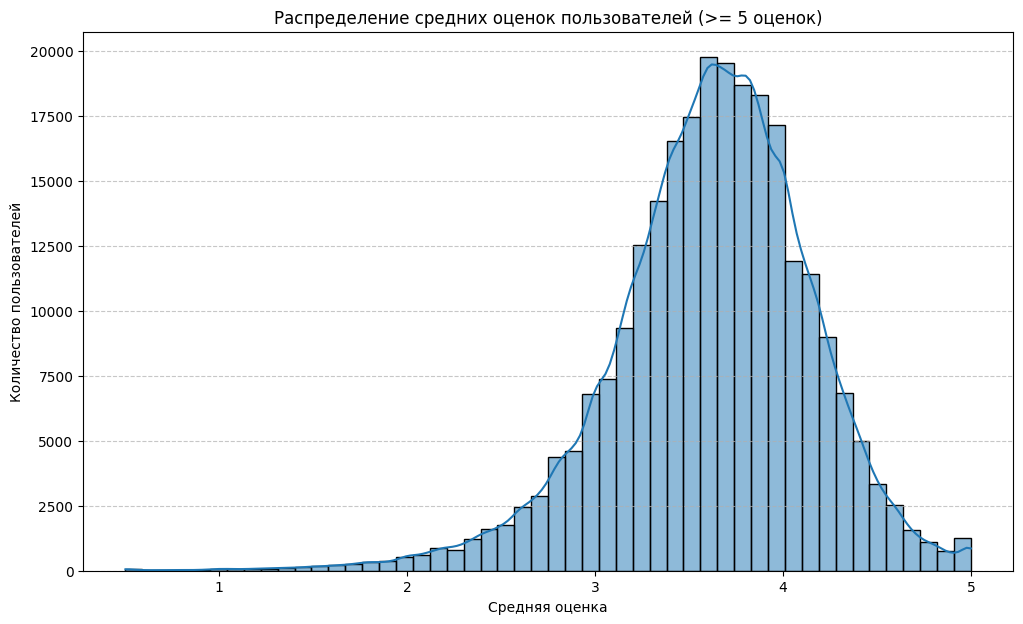

Описательная статистика по средним оценкам пользователей:


,average_rating
count,256051.000000
mean,3.615015
std,0.537312
min,0.500000
25%,3.318182
50%,3.650794
75%,3.966667
max,5.000000


In [ ]:
# Гистограмма распределения средних оценок пользователей
plt.figure(figsize=(12, 7))
sns.histplot(users_avg_rating['average_rating'], bins=50, kde=True)
plt.title('Распределение средних оценок пользователей (>= 5 оценок)')
plt.xlabel('Средняя оценка')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Описательная статистика по средним оценкам пользователей:")
display(users_avg_rating['average_rating'].describe())

### Анализ распределения средних оценок пользователей по жанрам

Теперь, чтобы найти более сложные паттерны поведения пользователей, давайте проанализируем, как распределяются средние оценки пользователей *внутри каждого жанра*. Нас интересуют жанры, для которых это распределение будет иметь несколько "холмов" (мультимодальное распределение), что может указывать на наличие различных групп предпочтений пользователей в рамках одного жанра.

Расчет средних оценок пользователей для каждого жанра...
Построение графиков для жанров с достаточным количеством данных...


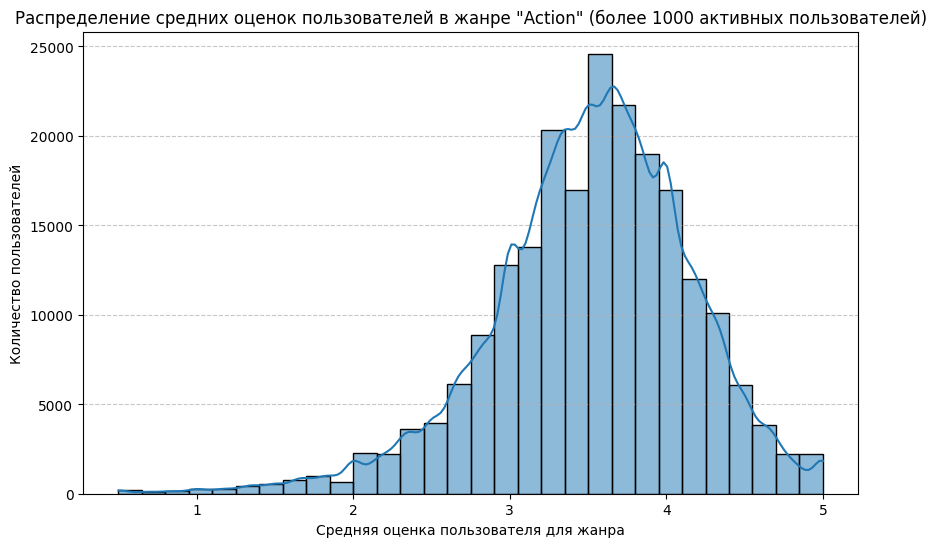

--------------------------------------------------


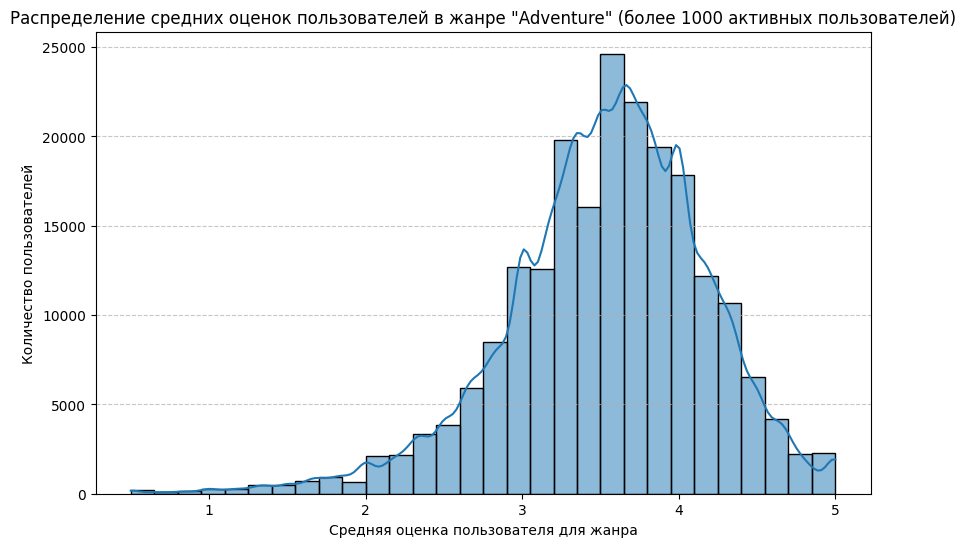

--------------------------------------------------


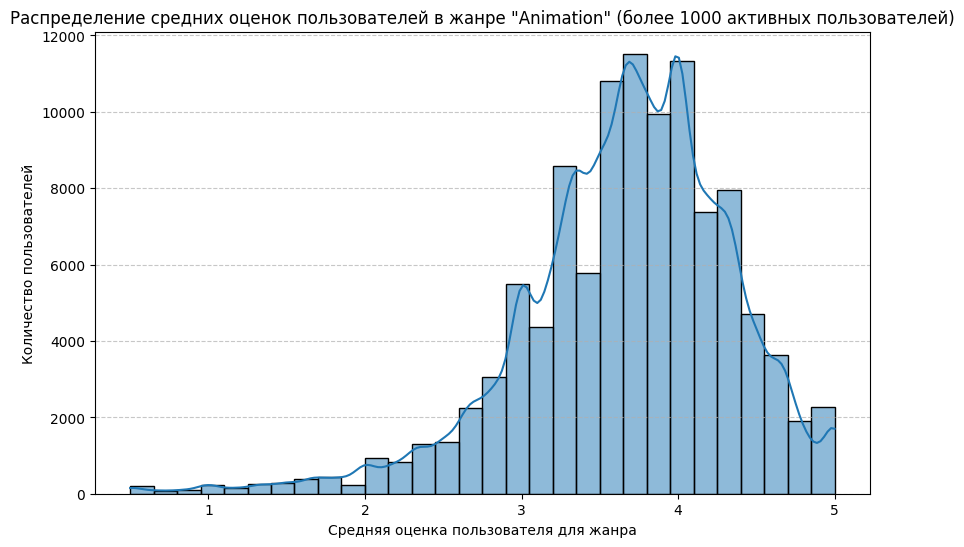

--------------------------------------------------


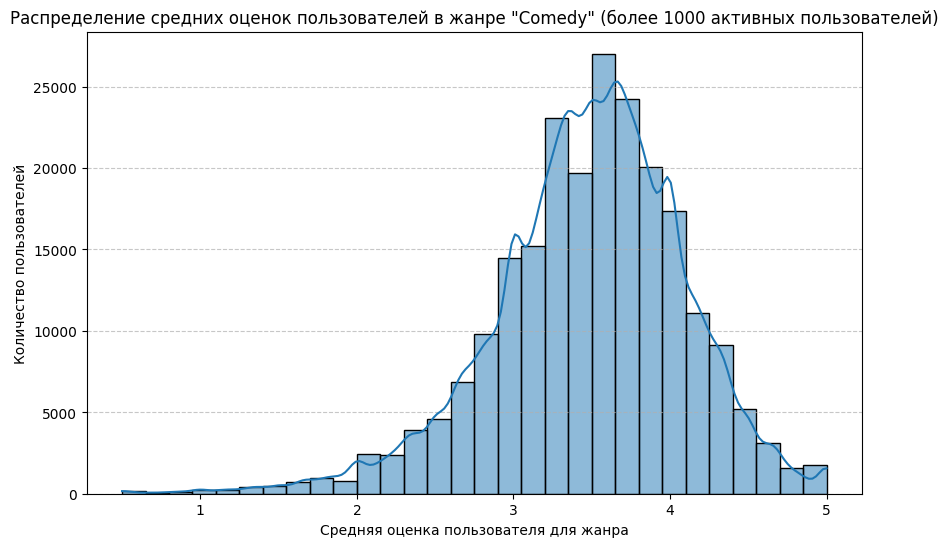

--------------------------------------------------


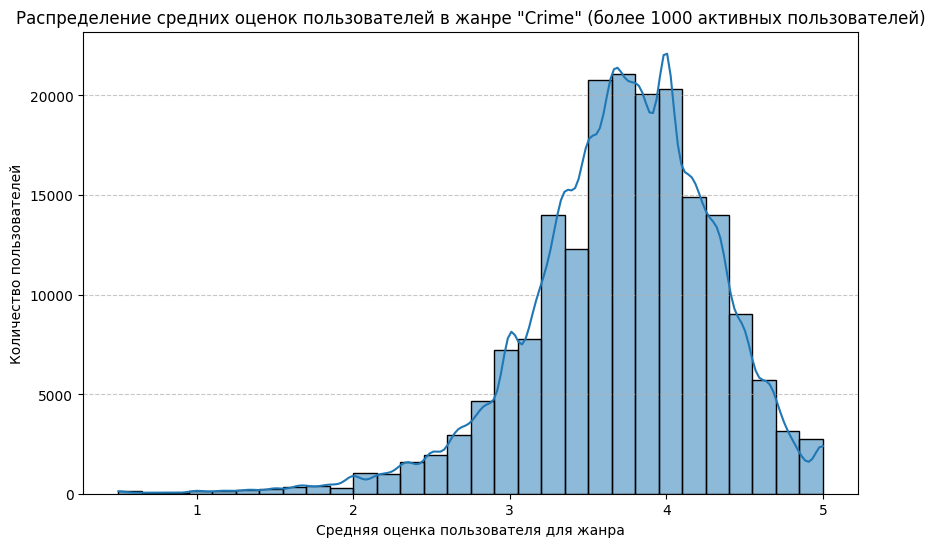

--------------------------------------------------


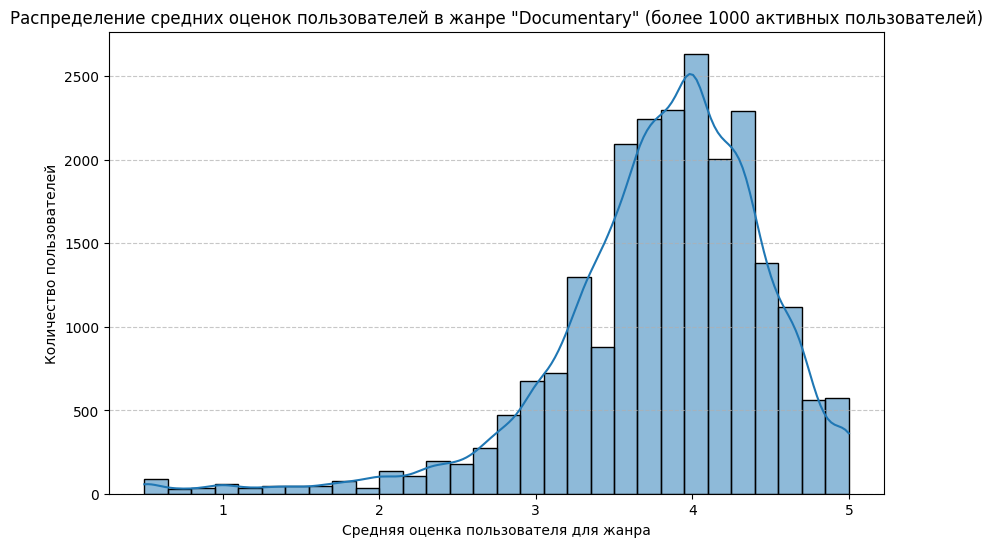

--------------------------------------------------


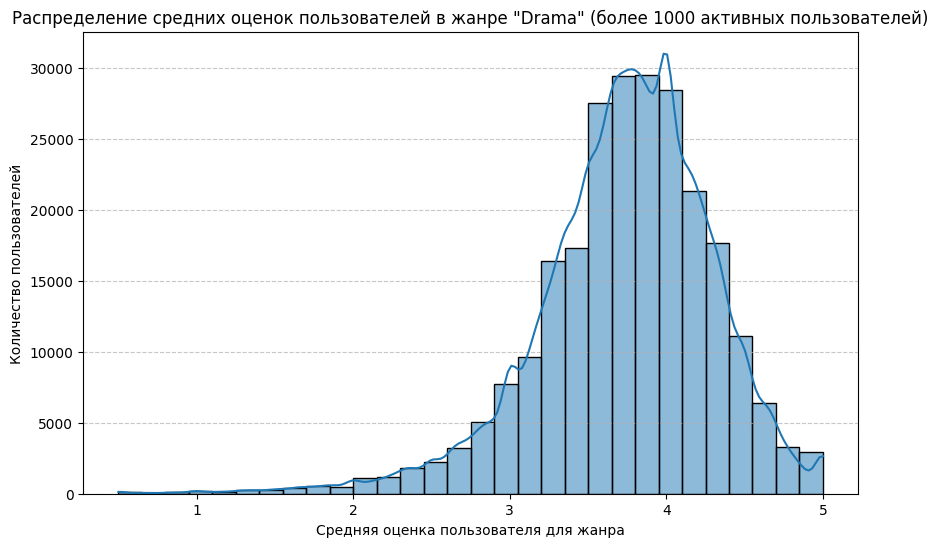

--------------------------------------------------


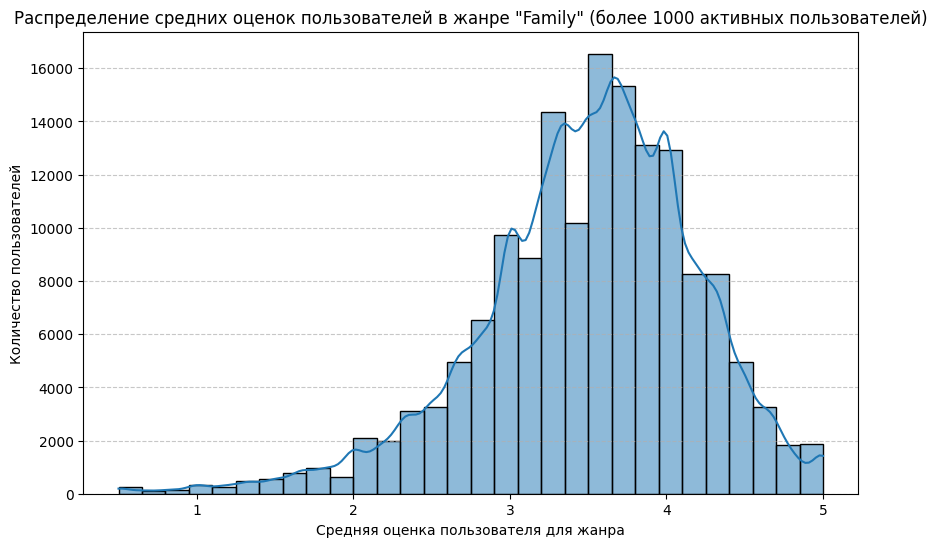

--------------------------------------------------


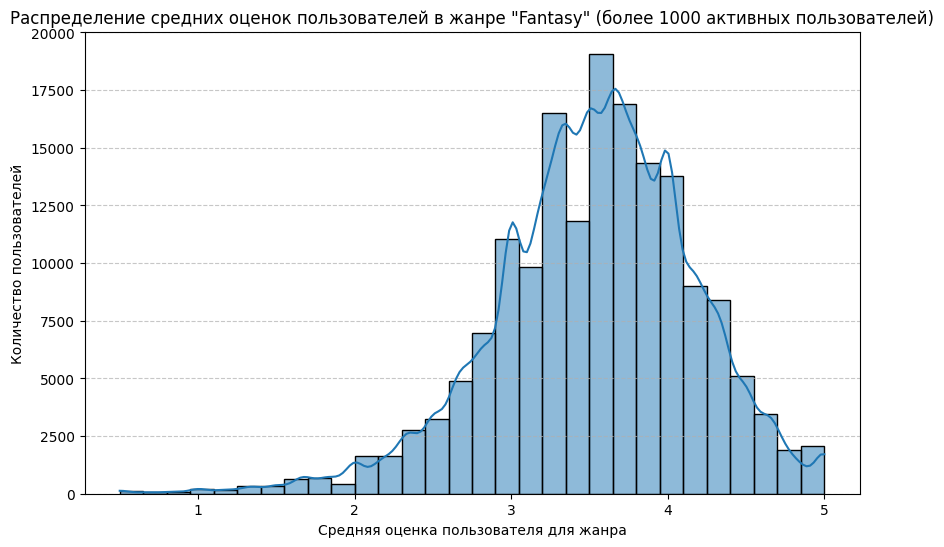

--------------------------------------------------


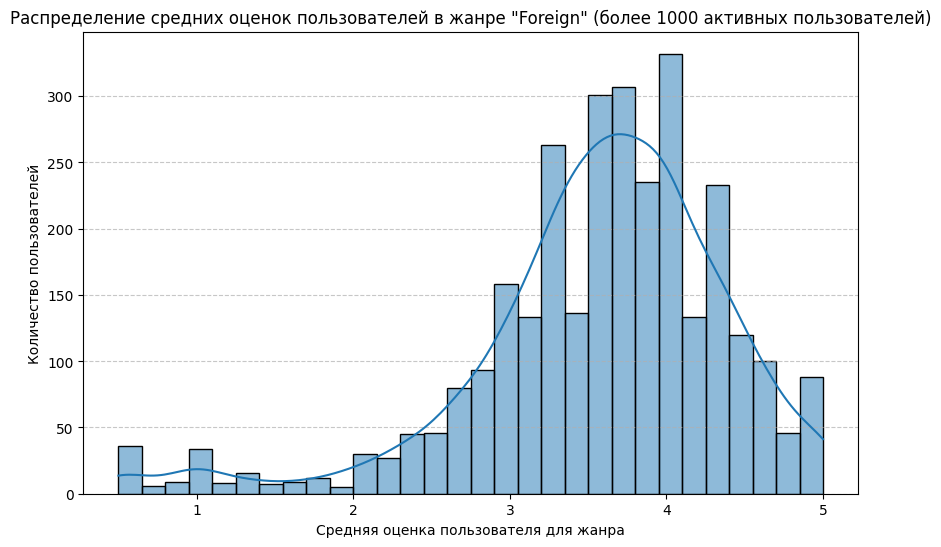

--------------------------------------------------


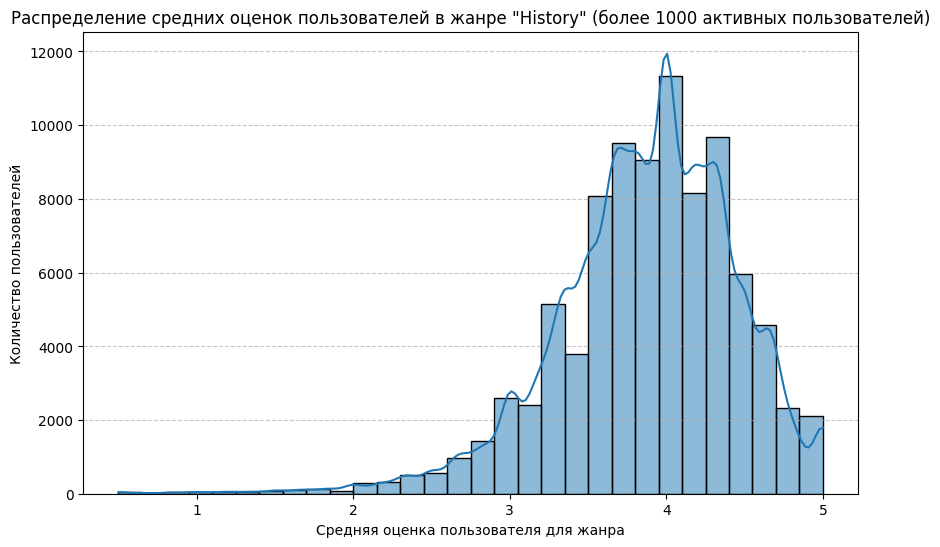

--------------------------------------------------


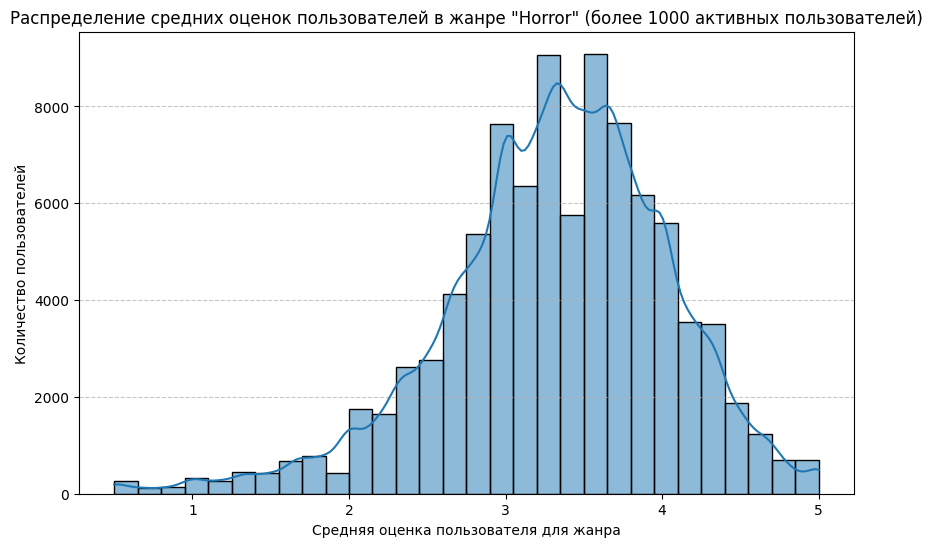

--------------------------------------------------


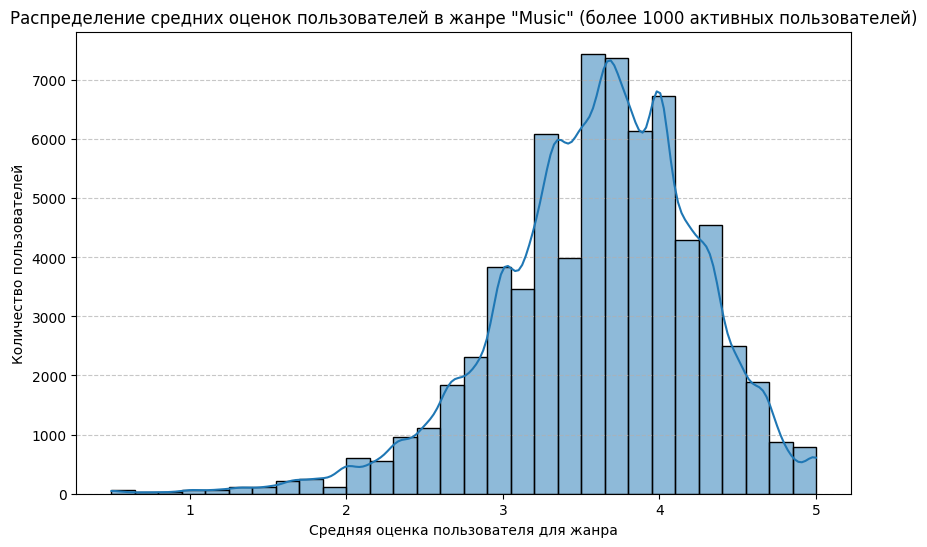

--------------------------------------------------


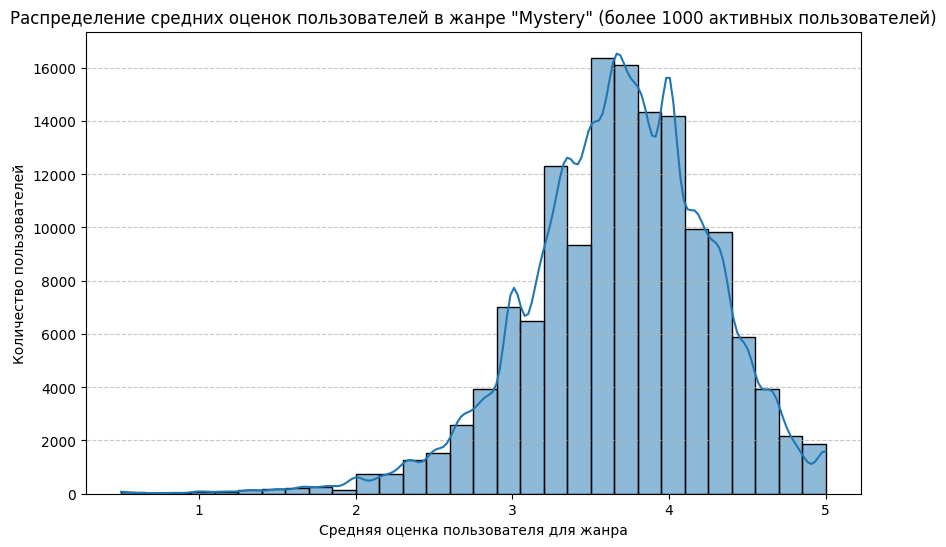

--------------------------------------------------


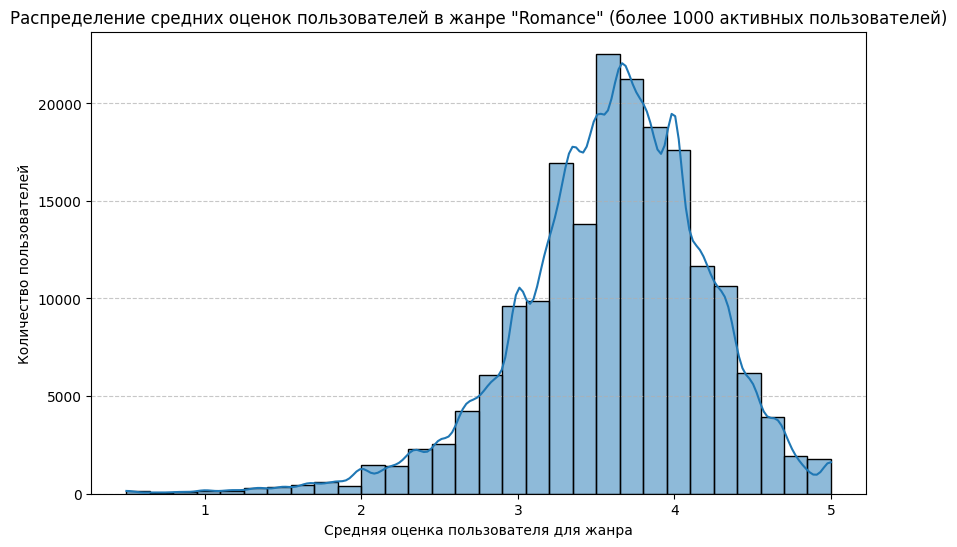

--------------------------------------------------


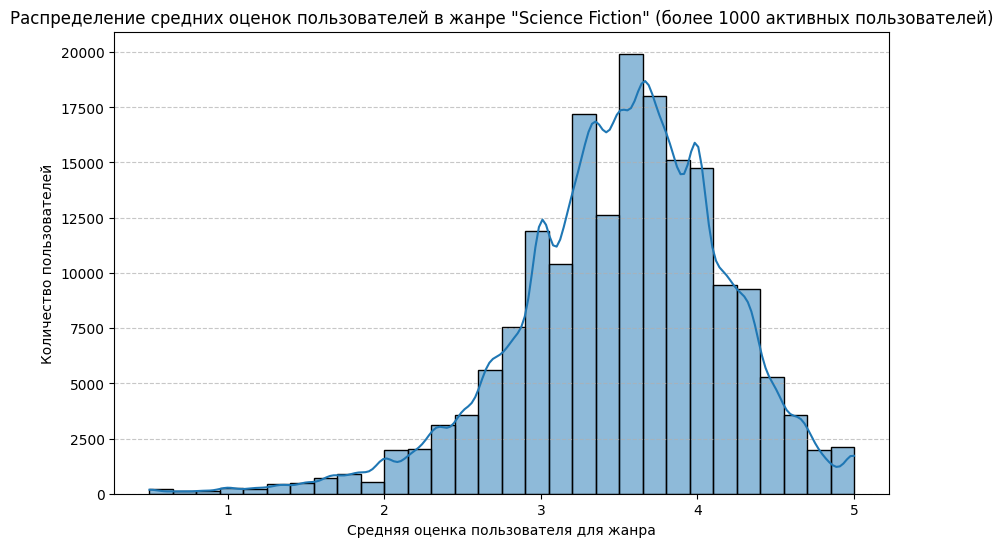

--------------------------------------------------


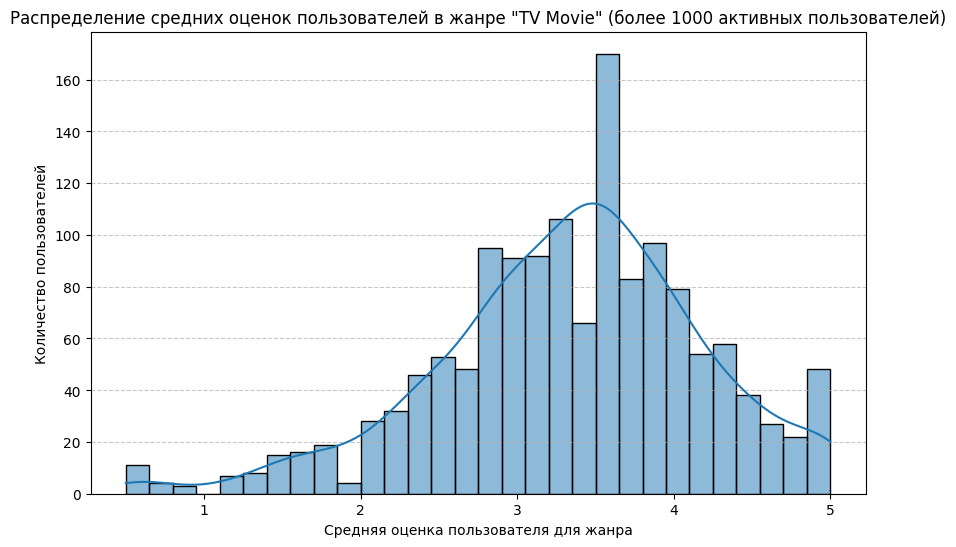

--------------------------------------------------


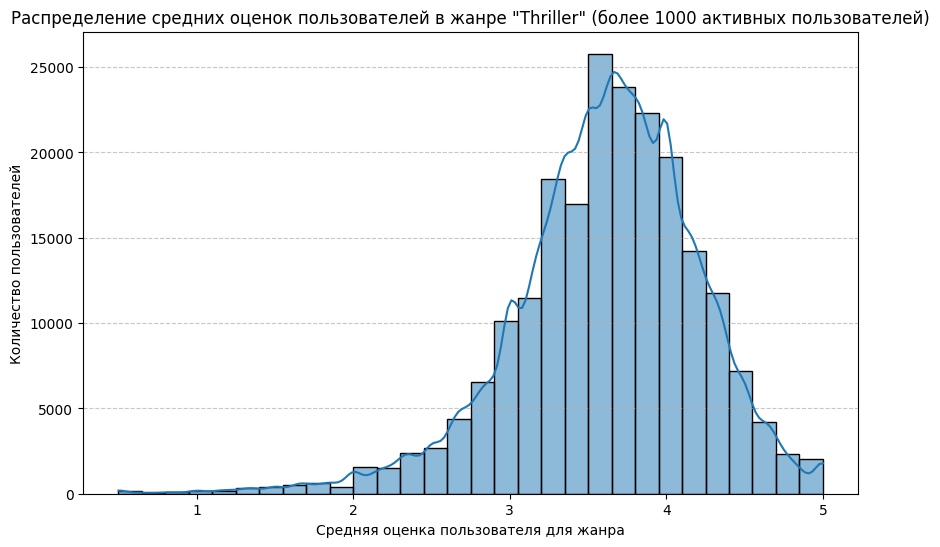

--------------------------------------------------


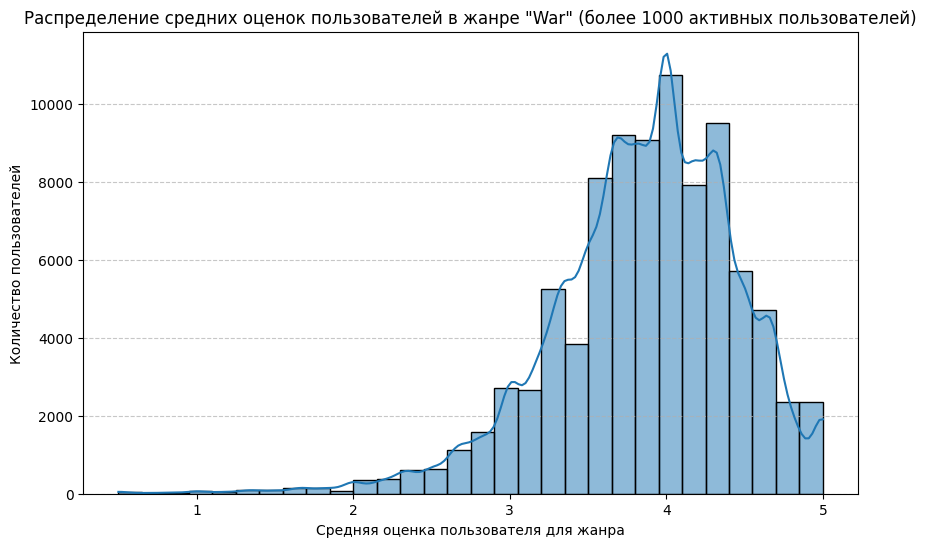

--------------------------------------------------


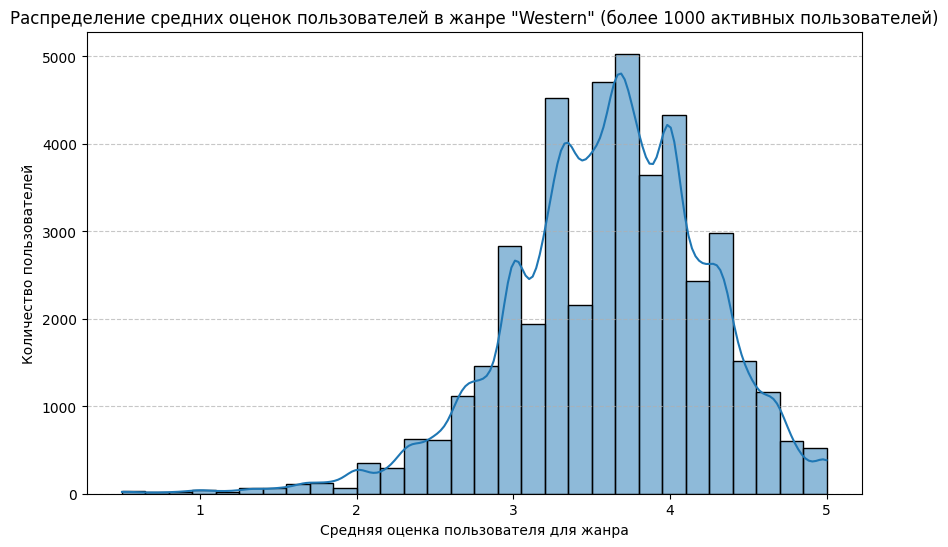

--------------------------------------------------
Построено графиков для 20 жанров.

Завершено. Проанализируйте графики на наличие нескольких 'холмов' (мод) в распределении, которые указывают на явные группы предпочтений пользователей внутри жанра.


In [ ]:
# Определяем минимальное количество оценок пользователя для жанра
# Это поможет избежать выбросов и сделает среднюю оценку более надежной
min_ratings_per_user_in_genre = 3

# Получаем список уникальных жанров, которые мы уже отфильтровали по количеству фильмов
unique_genres = genre_stats_filtered['genres'].tolist()

# Словарь для хранения распределений средних оценок по жанрам
genre_avg_rating_distributions = {}

print("Расчет средних оценок пользователей для каждого жанра...")

for genre in unique_genres:
    # 1. Получаем ID фильмов, принадлежащих текущему жанру
    genre_movie_ids = movies_filtered[movies_filtered['genres'].apply(lambda x: genre in x)]['id'].unique()

    # 2. Фильтруем оценки, чтобы оставить только те, что относятся к фильмам этого жанра
    ratings_for_genre = ratings[ratings['tmdbId'].isin(genre_movie_ids)]

    # 3. Подсчитываем количество оценок, сделанных каждым пользователем в этом жанре
    user_ratings_count_in_genre = ratings_for_genre.groupby('userId')['rating'].count().reset_index(name='genre_rating_count')

    # 4. Отбираем пользователей, которые оценили достаточно фильмов в этом жанре
    active_users_in_genre = user_ratings_count_in_genre[user_ratings_count_in_genre['genre_rating_count'] >= min_ratings_per_user_in_genre]

    # 5. Если есть активные пользователи, рассчитываем их среднюю оценку для фильмов этого жанра
    if not active_users_in_genre.empty:
        avg_rating_per_user_for_genre = ratings_for_genre[
            ratings_for_genre['userId'].isin(active_users_in_genre['userId'])
        ].groupby('userId')['rating'].mean().reset_index(name='average_genre_rating')

        if not avg_rating_per_user_for_genre.empty:
            gen_dist = avg_rating_per_user_for_genre['average_genre_rating']
            # Отфильтруем распределения с очень малым количеством уникальных значений (например, все ставят 5.0)
            if len(gen_dist.unique()) > 1:
                gen_dist.name = genre # Для лучшего отображения в plt
                gen_dist = gen_dist.to_frame() # Преобразуем Series в DataFrame для сохранения метаданных
                gen_dist['genre'] = genre # Добавляем столбец с именем жанра
                genre_avg_rating_distributions[genre] = gen_dist

print("Построение графиков для жанров с достаточным количеством данных...")

# Чтобы избежать слишком большого количества графиков, покажем только для жанров с более чем 1000 активных пользователей
# Это значение можно будет скорректировать по необходимости
min_users_for_plotting = 1000

plotted_genres_count = 0
for genre, distribution_df in genre_avg_rating_distributions.items():
    if len(distribution_df) >= min_users_for_plotting:
        plt.figure(figsize=(10, 6))
        sns.histplot(distribution_df[genre], bins=30, kde=True) # Использование `genre` вместо 'average_genre_rating'
        plt.title(f'Распределение средних оценок пользователей в жанре "{genre}" (более {min_users_for_plotting} активных пользователей)')
        plt.xlabel('Средняя оценка пользователя для жанра')
        plt.ylabel('Количество пользователей')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        print("-" * 50)
        plotted_genres_count += 1

if plotted_genres_count == 0:
    print(f"Не найдено жанров с количеством активных пользователей более {min_users_for_plotting} для построения графиков.")
else:
    print(f"Построено графиков для {plotted_genres_count} жанров.")

print("\nЗавершено. Проанализируйте графики на наличие нескольких 'холмов' (мод) в распределении, которые указывают на явные группы предпочтений пользователей внутри жанра.")